Set up working environment

In [1]:
# Import path libraries
import os
import sys
import pathlib

# Define paths
project_path = pathlib.Path("../").resolve()
data_path = project_path / "data" / "clean" / "06clinical_data_selected.parquet"
results_path = project_path / "results" / "risk_scores_validation"

# Add the project path to sys.path if it's not already there
if str(project_path) not in sys.path:
    sys.path.append(str(project_path))

print(f"Loading data from: {data_path}")
print(f"Saving results to: {results_path}")

Loading data from: /workspaces/TFM/data/clean/06clinical_data_selected.parquet
Saving results to: /workspaces/TFM/results/risk_scores_validation


Load modules

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, roc_curve


Load data

In [3]:
df = pd.read_parquet(data_path)
columns = df.filter(like='score_').columns.to_list()
columns.append("AF_recurrence")

df = df[columns].rename(columns=lambda column: column.removeprefix("score_"))
df.head()

,chad2ds2_vasc,hatch,chads2,baseaf2,mblater,AF_recurrence
0,4.0,2.0,2.0,2.0,1.0,no
1,0.0,0.0,0.0,0.0,1.0,no
2,2.0,0.0,0.0,2.0,NaN,no
3,1.0,0.0,0.0,1.0,2.0,yes
4,3.0,1.0,2.0,4.0,3.0,no


,score,n_samples,roc_auc,average_precision
3,baseaf2,720,0.633194,0.482159
0,chad2ds2_vasc,720,0.579784,0.412050
4,mblater,659,0.576927,0.439085
2,chads2,720,0.551094,0.385195
1,hatch,720,0.541565,0.381638


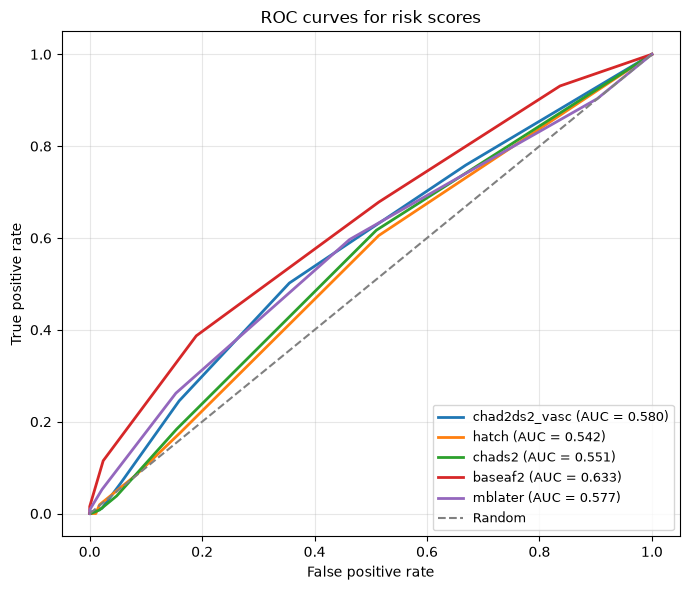

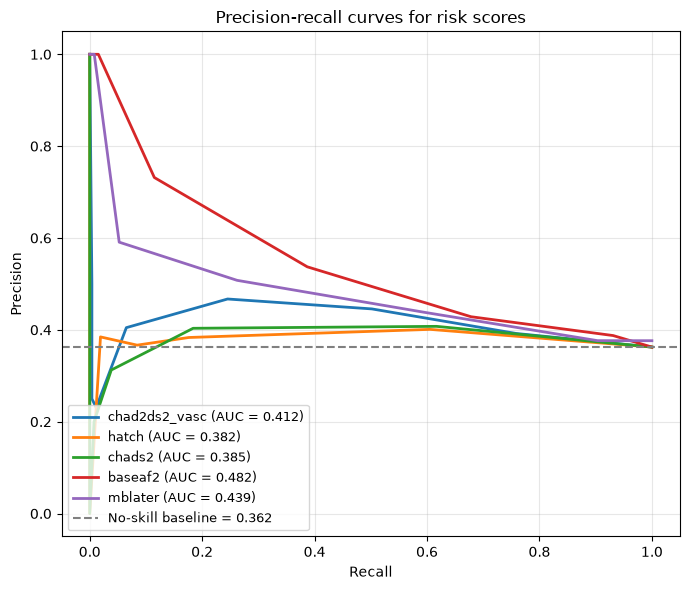

In [4]:
# Evaluate the risk scores with ROC and precision-recall curves
results_path.mkdir(parents=True, exist_ok=True)

target = df["AF_recurrence"].astype(str).map({"no": 0, "yes": 1})
if target.isna().any():
    unexpected_values = df.loc[target.isna(), "AF_recurrence"].dropna().unique()
    raise ValueError(f"Unexpected AF_recurrence values: {unexpected_values}")

score_columns = [column for column in df.columns if column != "AF_recurrence"]
evaluation_rows = []
roc_plot_data = []
pr_plot_data = []

for column in score_columns:
    mask = df[column].notna() & target.notna()
    y_true = target.loc[mask].astype(int)
    y_score = df.loc[mask, column].astype(float)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)
    average_precision = average_precision_score(y_true, y_score)

    evaluation_rows.append(
        {
            "score": column,
            "n_samples": int(mask.sum()),
            "roc_auc": roc_auc,
            "average_precision": average_precision,
        }
    )
    roc_plot_data.append((column, fpr, tpr, roc_auc))
    pr_plot_data.append((column, recall, precision, average_precision))

evaluation_df = pd.DataFrame(evaluation_rows).sort_values("roc_auc", ascending=False)
display(evaluation_df)
evaluation_df.to_csv(results_path / "risk_scores_metrics.csv", index=False)

prevalence = target.mean()

fig_roc, ax_roc = plt.subplots(figsize=(7, 6))
for column, fpr, tpr, roc_auc in roc_plot_data:
    ax_roc.plot(fpr, tpr, linewidth=2, label=f"{column} (AUC = {roc_auc:.3f})")
ax_roc.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random")
ax_roc.set_title("ROC curves for risk scores")
ax_roc.set_xlabel("False positive rate")
ax_roc.set_ylabel("True positive rate")
ax_roc.legend(loc="lower right", fontsize=9)
ax_roc.grid(alpha=0.3)
fig_roc.tight_layout()
plt.show()

fig_pr, ax_pr = plt.subplots(figsize=(7, 6))
for column, recall, precision, average_precision in pr_plot_data:
    ax_pr.plot(recall, precision, linewidth=2, label=f"{column} (AUC = {average_precision:.3f})")
ax_pr.axhline(prevalence, linestyle="--", color="grey", label=f"No-skill baseline = {prevalence:.3f}")
ax_pr.set_title("Precision-recall curves for risk scores")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.legend(loc="lower left", fontsize=9)
ax_pr.grid(alpha=0.3)
fig_pr.tight_layout()
plt.show()